In [1]:
from pygom.model.model_spec import ModelSpec
from pygom.model.transition import Event, Transition

from pygom.model.ode_utils.variable_store import StateStore, ParameterStore, DerivedParameterStore

from pygom.model.ode_variable import State, Parameter, DerivedParameter, CallableParameter

from pygom.model._model_errors import InputError

import pytest
import numpy as np

# Adding states

## In string form (initially and retroactively)

In [2]:
state_list = ['S', 'I', 'R']

state_store = StateStore(state_list)

state_store.add('E')
state_store.add(['V', 'D'])

# Don't allow duplicate state
with pytest.raises(InputError):
    state_store.add('S')

# Don't variable name whic halready exists in another namespace
with pytest.raises(InputError):
    state_store.add('X', all_symbols={'X'})

## In State form (and mixed)

In [3]:
state_list = [
    State(ID='S', limits=(0, np.inf), initial_value=100),
    State(ID='I'),
    State(ID='R'),
    'E'
]

state_store = StateStore(state_list)

# Common dunder methods and properties

In [4]:
print(state_store.get_index('S'))
print(len(state_store))
print('S' in state_store)
print('Z' in state_store)
print(state_store['S'])

1
4
True
False
S


In [5]:
common_methods = [
    'id_list',
    'symbol_list',
    'lower_limit_list',
    'upper_limit_list',
    'full_list',
    'symbol_dict',
    'id_namespace',
    'symbol_namespace'
]

for common_method in common_methods:
    print(f"Property: {common_method}")
    print(getattr(state_store, common_method), end="\n\n")

Property: id_list
['S', 'I', 'R', 'E']

Property: symbol_list
[S, I, R, E]

Property: lower_limit_list
[0, 0, 0, 0]

Property: upper_limit_list
[inf, inf, inf, inf]

Property: full_list
[State('S', S, None, (0, inf)), State('I', I, None, (0, inf)), State('R', R, None, (0, inf)), State('E', E, None, (0, inf))]

Property: symbol_dict
OrderedDict([('S', S), ('I', I), ('R', R), ('E', E)])

Property: id_namespace
{'S', 'E', 'I', 'R'}

Property: symbol_namespace
{R, S, I, E}



# Params store

In [6]:
param_list = ['beta', 'gamma']
param_store = ParameterStore(param_list)

In [7]:
param_list = [
    Parameter(ID='beta', limits=(0, np.inf)),
    Parameter(ID='gamma')
]

param_store = ParameterStore(param_list)

In [8]:
print(param_store.get_index('beta'))
print(len(param_store))
print('Z' in param_store)
print(param_store['gamma'])

1
2
False
gamma


In [9]:
for common_method in common_methods:
    print(f"Property: {common_method}")
    print(getattr(param_store, common_method), end="\n\n")

Property: id_list
['beta', 'gamma']

Property: symbol_list
[beta, gamma]

Property: lower_limit_list
[0, -inf]

Property: upper_limit_list
[inf, inf]

Property: full_list
[Parameter('beta', beta, None, (0, inf)), Parameter('gamma', gamma, None, (-inf, inf))]

Property: symbol_dict
OrderedDict([('beta', beta), ('gamma', gamma)])

Property: id_namespace
{'gamma', 'beta'}

Property: symbol_namespace
{beta, gamma}



# Param specific

In [10]:
param_list = ['beta', 'gamma']
param_store = ParameterStore(param_list)

print(param_store.id_value_dict)
print(param_store.value_list)
param_store.set_values({'beta': 0.3})
print(param_store.id_value_dict)
print(param_store.value_list)
param_store.set_values({'gamma': 0.25})
print(param_store.id_value_dict)
print(param_store.value_list)

param_store.set_values({'gamma': ('exponential', {'scale': 10.0})})
print(param_store.id_value_dict)
print(param_store.value_list)
param_store.new_realisation()
print(param_store.id_value_dict)
print(param_store.value_list)
param_store.new_realisation()
print(param_store.id_value_dict)
print(param_store.value_list)

OrderedDict([('beta', None), ('gamma', None)])
[None, None]
OrderedDict([('beta', 0.3), ('gamma', None)])
[0.3, None]
OrderedDict([('beta', 0.3), ('gamma', 0.25)])
[0.3, 0.25]
OrderedDict([('beta', 0.3), ('gamma', None)])
[0.3, None]
OrderedDict([('beta', 0.3), ('gamma', 4.432899899318129)])
[0.3, 4.432899899318129]
OrderedDict([('beta', 0.3), ('gamma', 3.3211570999564533)])
[0.3, 3.3211570999564533]


In [11]:
param_list = ['beta', 'gamma']
param_store = ParameterStore(param_list)

print(param_store._values_by_type)
param_store.set_values({'beta': 0.3})
print(param_store._values_by_type)
param_store.set_values({'gamma': ('exponential', {'scale': 10.0})})
print(param_store._values_by_type)

{'int': set(), 'float': set(), 'rv_frozen': set(), 'CallableParameter': set(), 'NoneType': {'gamma', 'beta'}}
{'int': set(), 'float': {'beta'}, 'rv_frozen': set(), 'CallableParameter': set(), 'NoneType': {'gamma'}}
{'int': set(), 'float': {'beta'}, 'rv_frozen': set(), 'CallableParameter': {'gamma'}, 'NoneType': set()}


In [12]:
param_list = ['beta', 'gamma']
param_store = ParameterStore(param_list)

print(param_store.all_values_set)
param_store.set_values({'beta': 0.3})
print(param_store.all_values_set)
param_store.set_values({'gamma': ('exponential', {'scale': 10.0})})
print(param_store.all_values_set)

False
False
True


In [13]:
param_list = ['beta', 'gamma']
param_store = ParameterStore(param_list)

print(param_store.has_stochastic_parameters)
param_store.set_values({'beta': 0.3})
print(param_store.has_stochastic_parameters)
param_store.set_values({'gamma': ('exponential', {'scale': 10.0})})
print(param_store.has_stochastic_parameters)

False
False
True


In [14]:
N = 100

param_list = [f'alpha_{i}' for i in range(N)]
param_store = ParameterStore(param_list)
assert len(param_store) == N

# Derived params

For this it is easier to build a model_spec

In [ ]:
states = ['S', 'I', 'R']
params = ['beta', 'gamma', 'mu']
derived_params = [('N', 'S+I+R')]

mod = ModelSpec(state=states, param=params, derived_param=derived_params)

assert mod.num_state == 3
assert mod.num_param == 3
assert mod.num_derived_param == 1



# Does caching save time when looking up param values

In [16]:
import time

param_list = [f'alpha_{i}' for i in range(100_000)]
param_store = ParameterStore(param_list)

In [17]:
nrep = 100

t1 = time.time()
for _ in range(nrep):
    x = param_store.id_list
    param_store._invalidate_cache()
t2 = time.time()

print(t2 - t1)

x = param_store.id_list
t1 = time.time()
for _ in range(nrep):
    x = param_store.id_list
t2 = time.time()

print(t2 - t1)

1.8856253623962402
0.0010006427764892578


In [18]:
nrep = 100

t1 = time.time()
for _ in range(nrep):
    x = param_store.symbol_dict
    param_store._invalidate_cache()
t2 = time.time()

print(t2 - t1)

x = param_store.symbol_dict
t1 = time.time()
for _ in range(nrep):
    x = param_store.symbol_dict
t2 = time.time()

print(t2 - t1)

5.40294075012207
0.0


In [19]:
param_vals = np.random.uniform(size = len(param_list))
param_dict = dict(zip(param_list, param_vals))

param_store.set_values(param_dict)

nrep = 100

t1 = time.time()
for _ in range(nrep):
    x = param_store.value_list
    param_store._invalidate_value_cache()
t2 = time.time()

print(t2 - t1)

x = param_store.value_list
t1 = time.time()
for _ in range(nrep):
    x = param_store.value_list
t2 = time.time()

print(t2 - t1)

1.8575270175933838
0.0


In [20]:
# N = 1000

# param_list = [f'alpha_{i}' for i in range(N)]
# param_store = ParameterStore(param_list)

# param_vals = N * [('exponential', {'scale': 10.0})]
# param_dict = dict(zip(param_list, param_vals))

# param_store.set_values(param_dict)

# param_store.value_list
# param_store.new_realisation()
# param_store.value_list

# Catch errors?

In [ ]:
import pytest

from pygom.model._model_errors import InputError

# Tried to use time (protected parameter)

with pytest.raises(InputError):
    states = ['S', 'I', 'R']
    params = ['beta', 'gamma', 't']

    mod = ModelSpec(state=states, param=params)

# Tried to have same state and param name

with pytest.raises(InputError):
    states = ['S', 'I', 'R']
    params = ['beta', 'gamma', 'I']

    mod = ModelSpec(state=states, param=params)

# Tried to use state name twice

with pytest.raises(InputError):
    states = ['S', 'I', 'R', 'R']
    params = ['beta', 'gamma']

    mod = ModelSpec(state=states, param=params)

# Tried to define derived parameter without required params

with pytest.raises(InputError):
    states = ['S', 'I', 'R']
    params = ['beta', 'gamma']
    derived_params = [('N', 'S+I+R+X')]

    mod = ModelSpec(state=states, param=params, derived_param=derived_params)

# Events and Transitions

In [ ]:
states = ['S', 'I', 'R']
params = ['beta', 'gamma', 'mu']
derived_params = [('N', 'S+I+R')]

In [ ]:
# Define via events

inf = Event(
    rate='beta*S*I/N',
    transition_list=[Transition(origin='S', destination='I')]
)

rec = Event(
    rate='gamma*I',
    transition_list=[Transition(origin='I', destination='R')]
)

event_list = [inf, rec]

mod1 = ModelSpec(state=states, param=params, derived_param=derived_params, event=event_list)

In [ ]:
# Define via transitions

inf = Transition(origin='S', destination='I', rate='beta*S*I/N')
rec = Transition(origin='I', destination='R', rate='gamma*I')

event_list = [inf, rec]

mod2 = ModelSpec(state=states, param=params, derived_param=derived_params, event=event_list)

In [ ]:
with pytest.raises(InputError):
    states = ['S', 'I']
    params = ['beta']
    inf = Transition(origin='S', destination='I', rate='beta*S*I*zeta')
    event_list = [inf]
    mod = ModelSpec(state=states, param=params, derived_param=derived_params, event=event_list)

In [ ]:
# mod1 == mod2

# Full Model

In [ ]:
from pygom.model.pygom_model import Model

living_states = ['S', 'E', 'I', 'R']
dead_states = ['D']
states = living_states + dead_states

params = ['beta', 'alpha', 'gamma', 'mu_b', 'mu_d', 'p']
derived_params = [('N', 'S+E+I+R')]

inf = Transition(origin='S', destination='E', rate='beta*S*I/N')
prog = Transition(origin='E', destination='I', rate='alpha*E')
rec = Transition(origin='I', destination='R', rate='gamma*I*(1-p)')
fatal = Transition(origin='I', destination='D', rate='gamma*I*p')

birth = Transition(destination='S', rate='mu_b*N')
deaths = [Transition(origin=state, rate=f'mu_d*{state}') for state in living_states]

event_list = [inf, prog, rec, fatal, birth] + deaths

mod = Model(state=states, param=params, derived_param=derived_params, event=event_list)

KeyError: 'state_change_matrix'

# Time scaling with model size

In [ ]:
# import time
# import numpy as np

# import matplotlib.pyplot as plt
# from scipy.stats import linregress

# def fit_and_plot_time_scaling(ns, times):
#     # linear fit in log-log space
#     log_n = np.log(ns)
#     log_t = np.log(times)

#     fit = linregress(log_n, log_t)

#     # fitted curve
#     n_fit = np.logspace(np.log10(min(ns)), np.log10(max(ns)), 100)
#     t_fit = np.exp(fit.intercept) * n_fit**fit.slope

#     plt.scatter(ns, times, label="Data")
#     plt.plot(n_fit, t_fit, "r",
#             label=fr"$t \propto n^{{{fit.slope:.2f}\pm{fit.stderr:.2f}}}$")
#     plt.xscale("log")
#     plt.yscale("log")
#     plt.xlabel("n")
#     plt.ylabel("Time")
#     plt.legend()
#     plt.show()

## Parameter value setting

In [ ]:
# build_times = []
# setting_times = []

# ns = [10_000, 20_000, 50_000, 100_000]

# for n in ns:
#     print(n)
#     params = [f'alpha_{i}' for i in range(n)]

#     nrep = 5
#     t1 = time.time()
#     for i in range(nrep):
#         mod = ModelSpec(param=params)
#     t2 = time.time()

#     build_times.append(t2 - t1)


#     vals = np.random.uniform(size = n)
#     param_dict = dict(zip(params, vals))

#     nrep = 20
#     t1 = time.time()
#     for i in range(nrep):
#         mod.parameters = param_dict
#     t2 = time.time()

#     setting_times.append(t2 - t1)

10000
20000
50000
100000


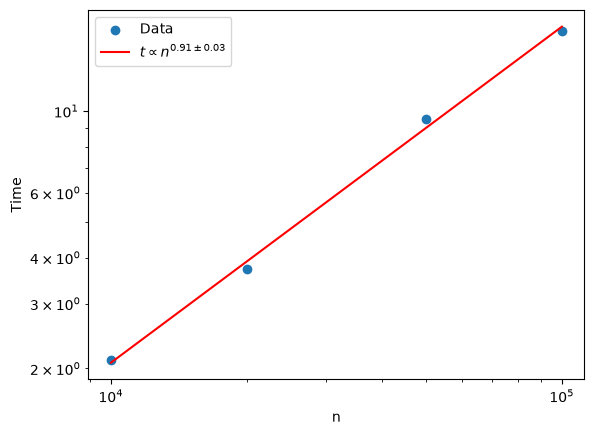

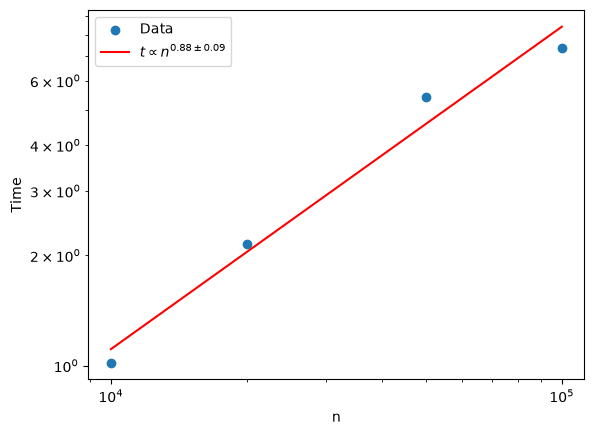

In [ ]:
# fit_and_plot_time_scaling(ns, build_times)
# fit_and_plot_time_scaling(ns, setting_times)

## Getting lists

In [ ]:
# build_times = []
# lookup_times = []

# ns = [10_000, 20_000, 30_000, 40_000, 50_000]

# for n in ns:
#     print(n)
#     states = [f'S_{i}' for i in range(n)]

#     nrep = 10
#     t1 = time.time()
#     for i in range(nrep):
#         mod = ModelSpec(state=states)
#     t2 = time.time()

#     build_times.append(t2 - t1)

#     nrep = 100
#     t1 = time.time()
#     for i in range(nrep):
#         mod.state_list
#     t2 = time.time()

#     lookup_times.append(t2 - t1)

10000
20000
30000
40000
50000


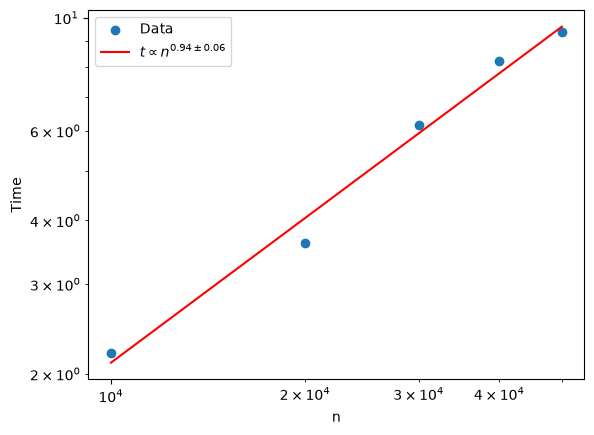

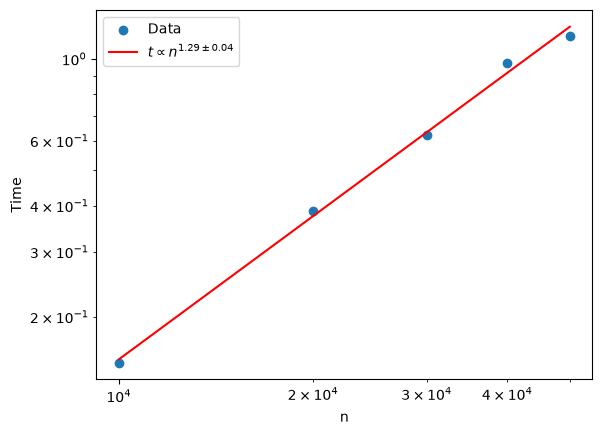

In [ ]:
# fit_and_plot_time_scaling(ns, build_times)
# fit_and_plot_time_scaling(ns, lookup_times)

In [ ]:
# states = ['S', 'I', 'R']
# params = ['beta', 'gammma', 'mu']
# derived_params = [('N', 'S+I+R')]

# t1 = Transition(origin='S', destination='I', rate='beta*S*I/N')
# t2 = Transition(origin='I', destination='R', rate='gamma*I')

# b1 = Transition(destination='S', rate='N*mu')

# d1 = Transition(origin='S', rate='mu * S')
# d2 = Transition(origin='I', rate='mu * I')
# d3 = Transition(origin='R', rate='mu * R')

# # mod = ModelSpec(state=states, param=params, event=[t1, t2, b1, d1, d2, d3])
# # mod = ModelSpec(state=states)

In [ ]:
# _transition_by_orig = {}
# _transition_by_dest = {}

# for event in mod.event_list:
#     for transition in event.transition_list:
#         orig, dest = transition.origin, transition.destination
#         if orig:
#             _transition_by_orig[orig] = {'event_id': event.ID, 'transition_id': transition.ID}
#         if dest:
#             _transition_by_dest[dest] = {'event_id': event.ID, 'transition_id': transition.ID}

# _transition_by_dest